In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df_path = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['gpn_score', 'gpn_star_llr_calibrated_mean', 'cadd_raw']

# plof_cols = ['loftee_hc', 'loftee_lc']
# plof_cols = ['loftee_hc', 'loftee_lc', 'consequence_start_lost', 'consequence_stop_lost']

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(existing_annos))
        # .union(set(plof_cols))
    )
    .with_columns(
        start_stop_lost = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    )
    .collect(engine='streaming')
)

anno

encode_ca_h3k4me3,consequence_start_lost,mobi_curated_disorder_priority,mobi_lip_full,encode_ca_tf,five_prime_utr_variant_consequence_ustop_lost,loftee_lc,encode_pls,five_prime_utr_variant_consequence_uaug_gained,consequence_splice_acceptor_variant,consequence_missense_variant,low_complexity_domain,non_mane_exonic,five_prime_utr_variant_consequence_uaug_lost,encode_pels,id,encode_tf,five_prime_utr_variant_consequence_uframeshift,loftee_hc,consequence_stop_lost,consequence_splice_donor_variant,ted_domain,region,non_mane_cds,consequence_stop_gained,not_in_encode,gene_name,consequence_frameshift_variant,encode_ca_ctcf,encode_dels,mane_exonic,mane_cds,five_prime_utr_variant_consequence_ustop_gained,encode_ca,start_stop_lost
bool,i32,bool,bool,bool,u8,i8,bool,u8,i32,i32,bool,bool,u8,bool,str,bool,u8,i8,i32,i32,bool,str,bool,i32,bool,str,i32,bool,bool,bool,bool,u8,bool,bool
false,0,false,true,false,0,0,false,0,0,1,false,false,0,false,"""chr15:64859998:G:C""",false,0,0,0,0,false,"""ENSG00000241839""",false,0,false,"""PLEKHO2""",0,false,true,true,true,0,false,false
false,0,true,true,false,0,0,false,0,0,1,true,false,0,false,"""chr1:202729885:A:T""",false,0,0,0,0,false,"""ENSG00000117139""",false,0,true,"""KDM5B""",0,false,false,true,true,0,false,false
false,0,false,false,false,0,0,false,0,0,1,false,false,0,false,"""chr11:125672628:A:G""",false,0,0,0,0,true,"""ENSG00000134940""",false,0,true,"""ACRV1""",0,false,false,true,true,0,false,false
false,0,false,false,false,0,0,false,0,0,1,false,false,0,false,"""chr1:202742800:C:T""",false,0,0,0,0,false,"""ENSG00000117139""",false,0,false,"""KDM5B""",0,false,true,true,true,0,false,false
false,0,true,false,false,0,0,false,0,0,1,false,false,0,false,"""chr1:202735550:A:G""",false,0,0,0,0,false,"""ENSG00000117139""",false,0,true,"""KDM5B""",0,false,false,true,true,0,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,0,false,false,false,0,0,false,0,0,0,false,false,0,false,"""chr1:32316756:C:CG""",false,0,1,0,0,true,"""ENSG00000116478""",false,0,false,"""HDAC1""",1,false,true,true,true,0,false,false
false,0,false,false,false,0,0,false,0,0,0,false,false,0,false,"""chr18:70020738:CAG:C""",false,0,1,0,0,false,"""ENSG00000176225""",false,0,true,"""RTTN""",1,false,false,true,true,0,false,false
false,0,false,false,false,0,0,false,0,0,0,false,false,0,false,"""chr22:28703536:CAAA:C""",false,0,0,0,0,true,"""ENSG00000183765""",false,0,true,"""CHEK2""",0,false,false,true,true,0,false,false


In [ ]:
selected_annos = anno_config_df.filter(
    pl.col('category').is_in(['plof_consequences']) # plof consequences
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )
    
    .filter(
        (pl.col('annotation_score') != 0)
    )
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr9:132327226:C:CA""","""ENSG00000107290""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
"""chr13:32337521:CAAAAG:C""","""ENSG00000139618""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
"""chr6:56529767:TC:T""","""ENSG00000151914""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
"""chr22:41809990:G:GGCTCT""","""ENSG00000100147""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
"""chr22:36320834:A:AG""","""ENSG00000100345""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
…,…,…,…,…,…,…
"""chr10:24584542:T:TG""","""ENSG00000107863""","""loftee_lc""",1.0,"""plof_consequences""",1,1.0
"""chr4:105275611:A:ATG""","""ENSG00000168769""","""loftee_lc""",1.0,"""plof_consequences""",1,1.0
"""chr4:105275569:CAG:C""","""ENSG00000168769""","""loftee_lc""",1.0,"""plof_consequences""",1,1.0


In [5]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [6]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [7]:
plof_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('corr_dir')
    )
    
    # C. Group by annotation and aggregate
    .group_by(['annotation'])
    .agg(
        n_vars = pl.col('id').n_unique(),
        median_pheno = pl.col('mean_pheno_value_dircor').median(),
        mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
        std_pheno = pl.col('mean_pheno_value_dircor').std(),
    )
    .with_columns(
        se_pheno = pl.col('std_pheno') / pl.col('n_vars').sqrt()
    )
    .with_columns(
        ci_low_pheno = pl.col('mean_pheno') - 1.96*pl.col('se_pheno'),
        ci_high_pheno = pl.col('mean_pheno') + 1.96*pl.col('se_pheno'),
    )
    .collect(engine='streaming')
)

plof_pheno_df

annotation,n_vars,median_pheno,mean_pheno,std_pheno,se_pheno,ci_low_pheno,ci_high_pheno
str,u64,f64,f64,f64,f64,f64,f64
"""consequence_stop_gained""",6157,0.309577,0.363417,0.828738,0.010562,0.342717,0.384118
"""consequence_frameshift_variant""",9561,0.263288,0.31925,0.85283,0.008722,0.302155,0.336345
"""consequence_splice_acceptor_va…",1804,0.305418,0.356108,0.790514,0.018612,0.319629,0.392587
"""consequence_stop_lost""",126,0.142572,0.178621,0.684608,0.06099,0.059081,0.298161
"""consequence_splice_donor_varia…",2298,0.269925,0.335231,0.800861,0.016706,0.302487,0.367976
"""consequence_start_lost""",336,0.173848,0.209961,0.703343,0.03837,0.134754,0.285167
"""loftee_hc""",18857,0.287814,0.344137,0.831615,0.006056,0.332267,0.356007
"""loftee_lc""",819,0.163905,0.211185,0.898156,0.031384,0.149672,0.272698


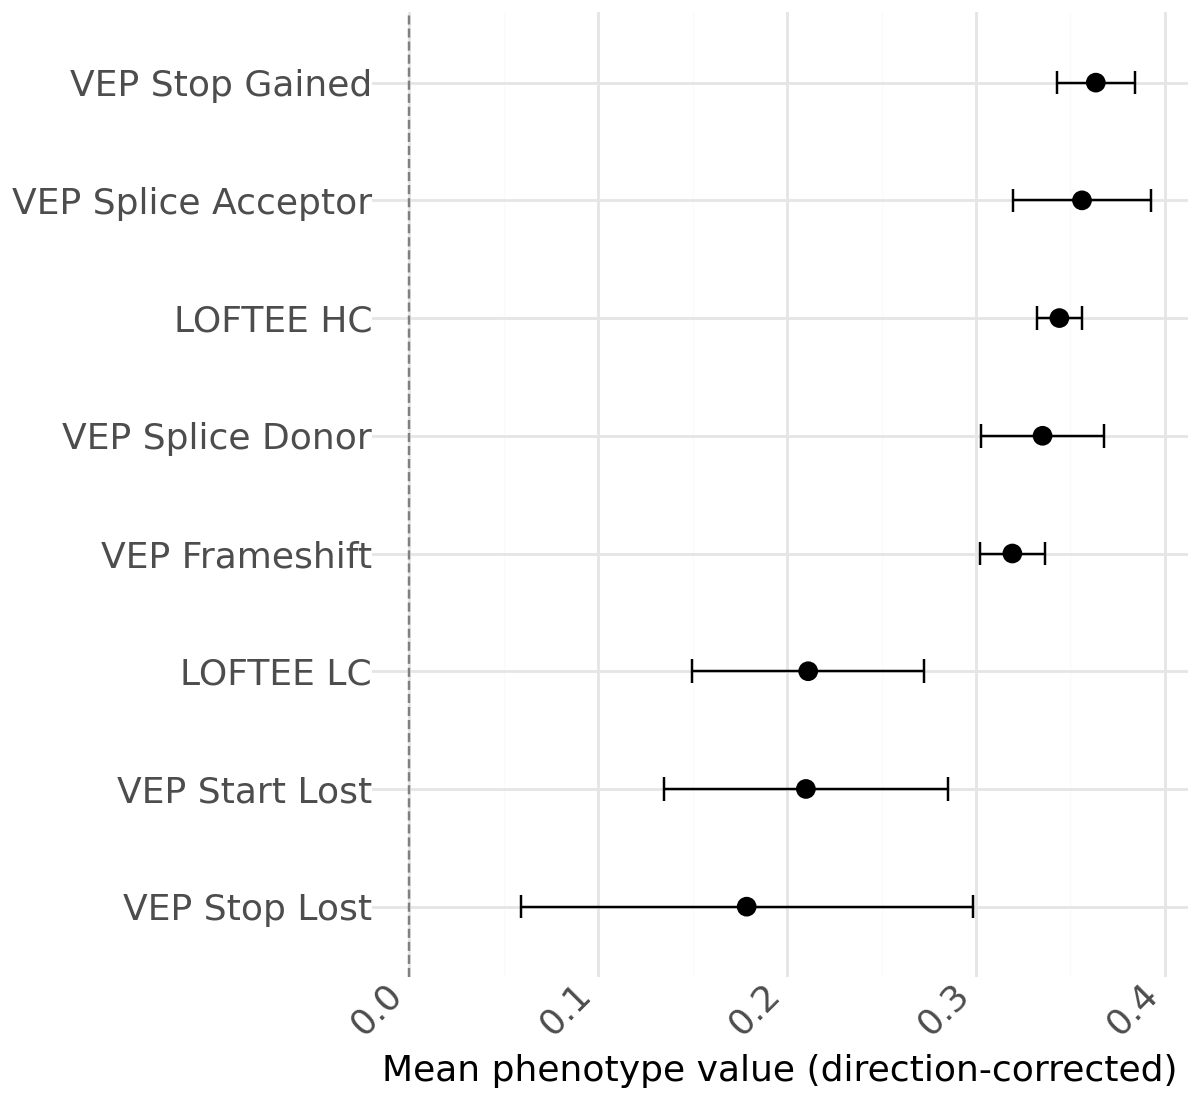

In [8]:
avg_plof_plot = (
    plof_pheno_df
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .to_pandas()
)

avg_plof_plot['label'] = pd.Categorical(
    avg_plof_plot['label'],
    categories=avg_plof_plot.sort_values('mean_pheno', ascending=True)['label'].unique(),
    ordered=True
)

(
    ggplot(
        avg_plof_plot,
        aes(x='label', y='mean_pheno')
        # aes(x='label', y='median_pheno')
    )
    + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + geom_point(size=3)
    + geom_errorbar(
        aes(ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.2,
    )
    + labs(
        x='', 
        y='Mean phenotype value (direction-corrected)'
    )
    + coord_flip()
    + theme_minimal()
    + theme(
        figure_size=(6, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Genome-wide scores

In [9]:
# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
gnomw_anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

gnomw_anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [17]:
gnomw_anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

plof_annos = avg_plof_plot['annotation'].to_list()
selected_annos = ['gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max']

gnomw_anno = (
    gnomw_anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(selected_annos))
        .union(set(plof_annos))
    )
    .collect(engine='streaming')

    .unpivot(
        index=set(['id', 'region', 'gene_name']).union(plof_annos),
        on=selected_annos,
        variable_name='annotation',
        value_name='annotation_score',
    )
    .unpivot(
        index = ['id', 'region', 'gene_name', 'annotation', 'annotation_score'],
        variable_name='plof_type',
        value_name='plof_score',
    )
    .filter(
        pl.col('plof_score') == 1
    )
    .join(
        gnomw_anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gnomw_anno_config_df.rename({
            'annotation':'plof_type', 
            'annotation_dir':'plof_dir',
            'label':'label_plof'
        }).select(['plof_type', 'plof_dir', 'label_plof']).unique(),
        on='plof_type'
    )
    .with_columns(
        annotation_score_dircorr = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

gnomw_anno


id,region,gene_name,annotation,annotation_score,plof_type,plof_score,color,label,annotation_dir,plof_dir,label_plof,annotation_score_dircorr
str,str,str,str,f32,str,i32,str,str,i8,i8,str,f32
"""chr1:202741695:G:A""","""ENSG00000117139""","""KDM5B""","""gpn_star_llr_calibrated_mean""",-10.388748,"""consequence_stop_gained""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Gained""",10.388748
"""chr1:42842738:G:T""","""ENSG00000164010""","""ERMAP""","""gpn_star_llr_calibrated_mean""",-4.154405,"""consequence_stop_gained""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Gained""",4.154405
"""chr1:202742501:G:A""","""ENSG00000117139""","""KDM5B""","""gpn_star_llr_calibrated_mean""",-10.810938,"""consequence_stop_gained""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Gained""",10.810938
"""chr17:60059489:A:C""","""ENSG00000068097""","""HEATR6""","""gpn_star_llr_calibrated_mean""",-8.899546,"""consequence_stop_gained""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Gained""",8.899546
"""chr1:212377684:G:A""","""ENSG00000065600""","""PACC1""","""gpn_star_llr_calibrated_mean""",-9.778584,"""consequence_stop_gained""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Gained""",9.778584
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr7:117587834:G:A""","""ENSG00000001626""","""CFTR""","""abexp_abs_max""",1.04481,"""consequence_splice_donor_varia…",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Splice Donor""",1.04481
"""chr1:247365284:G:A""","""ENSG00000162711""","""NLRP3""","""abexp_abs_max""",0.0,"""consequence_splice_donor_varia…",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Splice Donor""",0.0
"""chr17:39712049:T:C""","""ENSG00000141736""","""ERBB2""","""abexp_abs_max""",3.169872,"""consequence_splice_donor_varia…",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Splice Donor""",3.169872


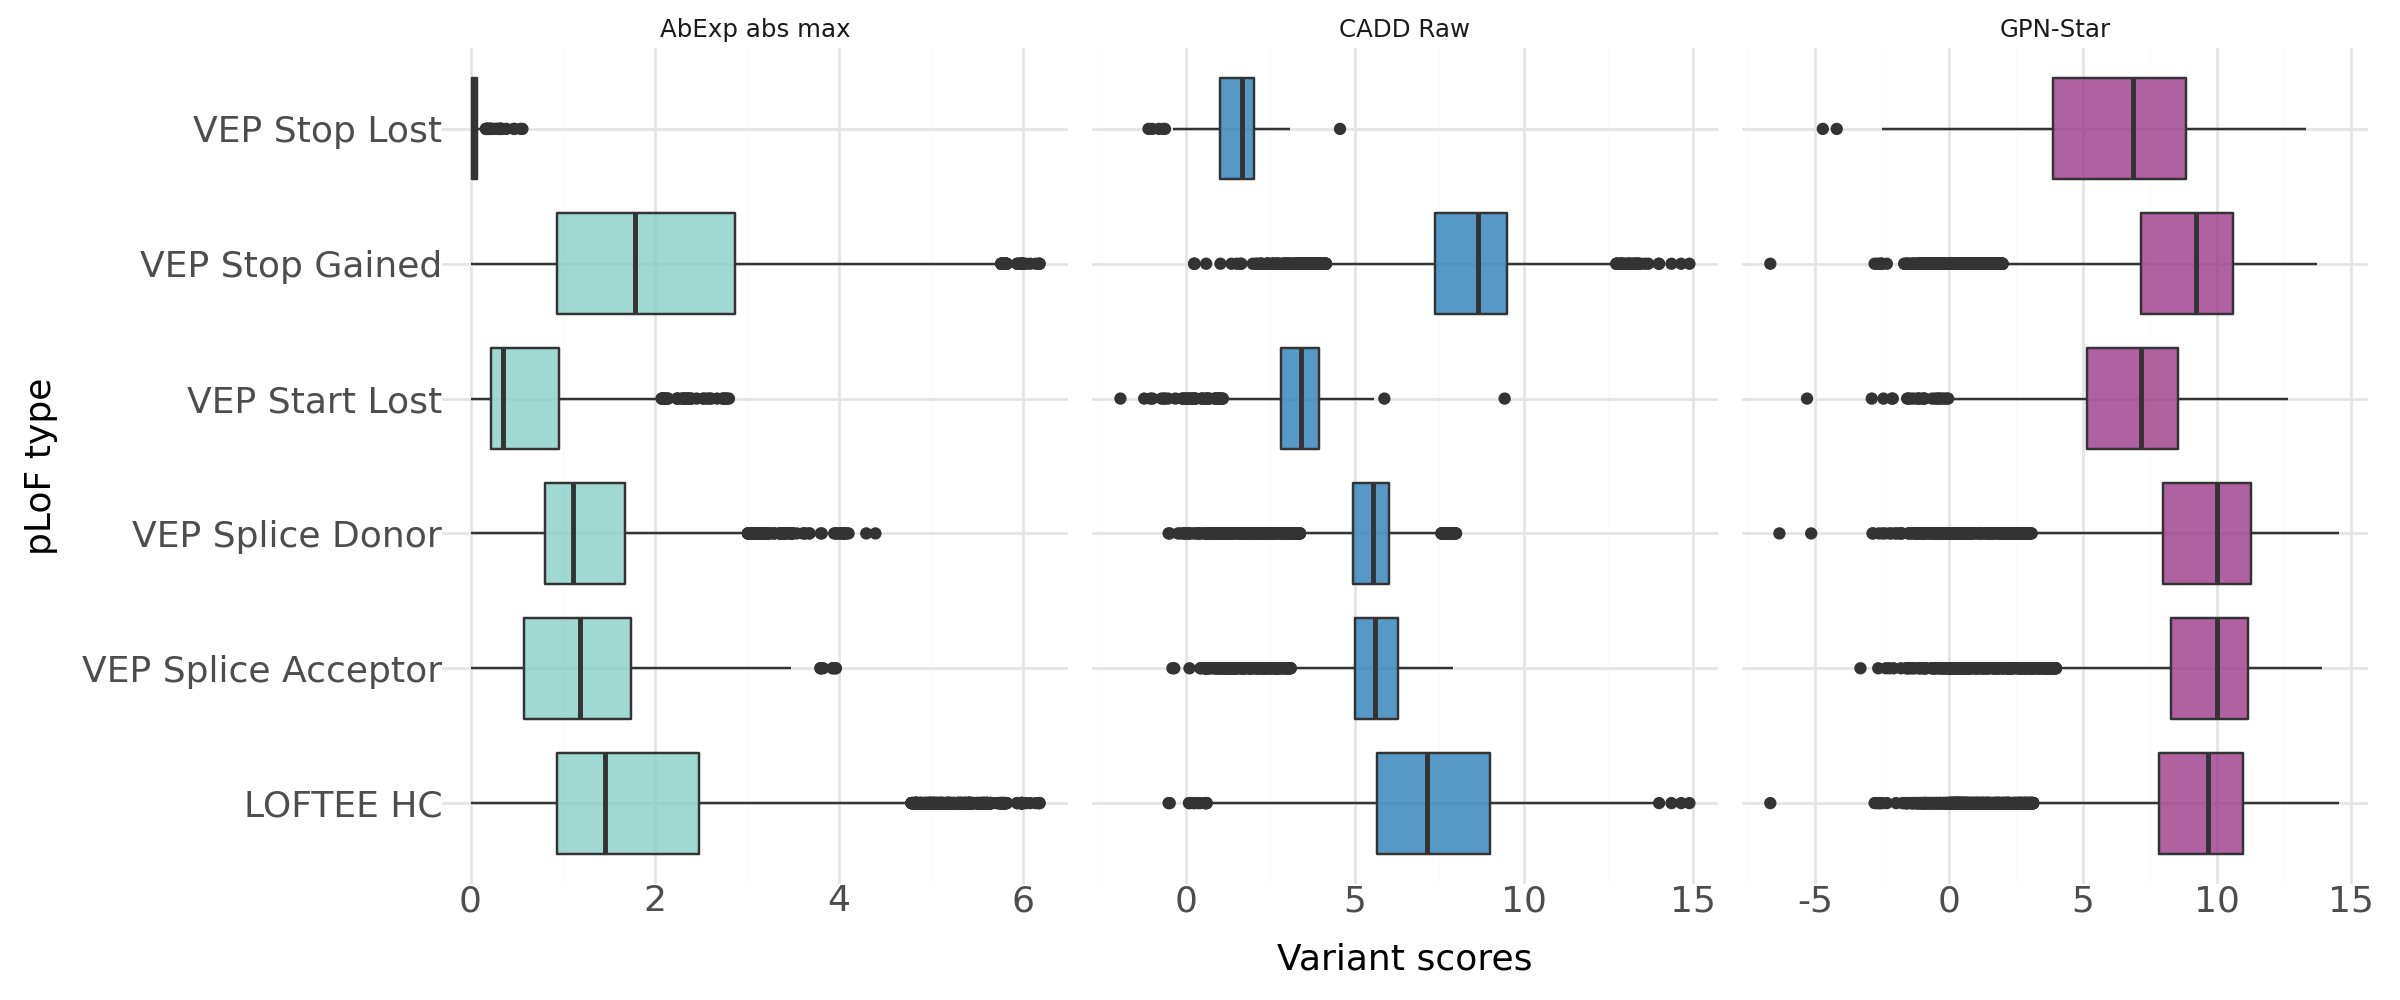

In [27]:
color_dict = dict(zip(gnomw_anno_config_df['label'], gnomw_anno_config_df['color']))

(
    ggplot(
        gnomw_anno,
        aes(y='annotation_score_dircorr', x='label_plof', fill='label')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + facet_wrap('~label', scales='free_x', ncol=3)
    + scale_fill_manual(values=color_dict)
    + labs(
        x='pLoF type',
        y='Variant scores'
    )
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(12, 5),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)